### 데이터 가공

## 1. 데이터를 읽어들여 bikes데이터 프레임 만들기

In [1]:
# folium 모듈 설치하기

In [2]:
!pip install folium


[notice] A new release of pip is available: 24.0 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
!pip install seaborn


[notice] A new release of pip is available: 24.0 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import platform

# 운영체제에 맞는 한글 폰트 설정
if platform.system() == 'Windows':
    plt.rc('font', family='Malgun Gothic')
elif platform.system() == 'Darwin': # Mac
    plt.rc('font', family='AppleGothic')
else: # Linux
    plt.rc('font', family='NanumGothic')

# 마이너스 기호 깨짐 방지
plt.rc('axes', unicode_minus=False)

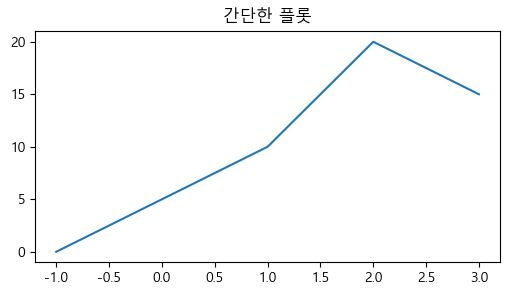

In [5]:
import matplotlib.pyplot as plt
plt.figure(figsize=(6, 3))
plt.plot([-1, 1, 2, 3], [0, 10, 20, 15])
plt.title('간단한 플롯')
plt.show()

In [6]:
# 모듈 import하기 / pandas, seaborn, matplotlib.pyplot, folium
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
import folium

In [7]:
# 6개의 파일로 나누어진 bike_rent파일을 하나씩 읽어오기

bikes_temp = {}         #빈 데이터 프레임

# 6개의 파일을 bikes_temp[0]~[5]까지 읽어 들인다
for i in range(6):
    bikes_temp[i] = pd.read_csv(f'data/bike_rent_{i+1}.csv', encoding='cp949', parse_dates=['대여일시']) # pd.read_csv

In [8]:
#각각 파일 확인
bikes_temp

{0:             자전거번호                대여일시  대여 대여소번호            대여 대여소명  이용시간  이용거리
 0       SPB-22040 2019-06-03 08:49:00       646  장한평역 1번출구 (국민은행앞)    27  1330
 1       SPB-07446 2019-06-03 08:33:00       526           용답토속공원 앞    54  1180
 2       SPB-20387 2019-06-05 08:27:00       646  장한평역 1번출구 (국민은행앞)    12  1930
 3       SPB-16794 2019-06-05 08:46:00       646  장한평역 1번출구 (국민은행앞)     6  1340
 4       SPB-18266 2019-06-10 08:27:00       529       장한평역 8번 출구 앞     5  1230
 ...           ...                 ...       ...                ...   ...   ...
 399994  SPB-16680 2019-06-28 17:14:00       316         종각역 1번출구 앞    16  2360
 399995  SPB-07874 2019-06-28 16:59:00       345         서울보증보험본사 앞    32  1880
 399996  SPB-21622 2019-06-28 16:44:00       526           용답토속공원 앞    64  6100
 399997  SPB-20056 2019-06-28 17:46:00       453  종로오가 지하쇼핑센터 14번출구     7   880
 399998  SPB-18692 2019-06-28 17:34:00       345         서울보증보험본사 앞    35  1820
 
 [399999 rows x 6 columns],
 1:    

In [9]:
bikes_temp[5]

,자전거번호,대여일시,대여 대여소번호,대여 대여소명,이용시간,이용거리
0,SPB-21524,2019-06-20 08:44:00,2202,청계산입구역 1번출구,8,790
1,SPB-08966,2019-06-20 18:00:00,2202,청계산입구역 1번출구,5,1470
2,SPB-09048,2019-06-20 17:56:00,2202,청계산입구역 1번출구,9,1820
3,SPB-05661,2019-06-20 20:40:00,2202,청계산입구역 1번출구,6,1490
4,SPB-05353,2019-06-20 20:41:00,2202,청계산입구역 1번출구,8,1480
...,...,...,...,...,...,...
315717,SPB-22438,2019-06-24 07:40:00,240,문래역 4번출구 앞,13,900
315718,SPB-24455,2019-06-25 07:34:00,240,문래역 4번출구 앞,6,880
315719,SPB-24557,2019-06-26 08:19:00,240,문래역 4번출구 앞,7,930
315720,SPB-00649,2019-06-27 07:38:00,240,문래역 4번출구 앞,11,1030


In [10]:
bikes_temp[0].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 399999 entries, 0 to 399998
Data columns (total 6 columns):
 #   Column    Non-Null Count   Dtype         
---  ------    --------------   -----         
 0   자전거번호     399999 non-null  object        
 1   대여일시      399999 non-null  datetime64[ns]
 2   대여 대여소번호  399999 non-null  int64         
 3   대여 대여소명   399999 non-null  object        
 4   이용시간      399999 non-null  int64         
 5   이용거리      399999 non-null  int64         
dtypes: datetime64[ns](1), int64(3), object(2)
memory usage: 18.3+ MB


In [11]:
# 6개의 파일을 최종 bikes파일로 데이터 프레임 만들어 bikes에 저장하기
# ignore_index 기존 인덱스를 무시하고 다시 순서를 0부터 정한다.
bikes = pd.concat(bikes_temp, ignore_index=True)
bikes.head()

,자전거번호,대여일시,대여 대여소번호,대여 대여소명,이용시간,이용거리
0,SPB-22040,2019-06-03 08:49:00,646,장한평역 1번출구 (국민은행앞),27,1330
1,SPB-07446,2019-06-03 08:33:00,526,용답토속공원 앞,54,1180
2,SPB-20387,2019-06-05 08:27:00,646,장한평역 1번출구 (국민은행앞),12,1930
3,SPB-16794,2019-06-05 08:46:00,646,장한평역 1번출구 (국민은행앞),6,1340
4,SPB-18266,2019-06-10 08:27:00,529,장한평역 8번 출구 앞,5,1230


In [12]:
bikes.tail()

,자전거번호,대여일시,대여 대여소번호,대여 대여소명,이용시간,이용거리
2215627,SPB-22438,2019-06-24 07:40:00,240,문래역 4번출구 앞,13,900
2215628,SPB-24455,2019-06-25 07:34:00,240,문래역 4번출구 앞,6,880
2215629,SPB-24557,2019-06-26 08:19:00,240,문래역 4번출구 앞,7,930
2215630,SPB-00649,2019-06-27 07:38:00,240,문래역 4번출구 앞,11,1030
2215631,SPB-14209,2019-06-28 07:37:00,240,문래역 4번출구 앞,6,1010


In [13]:
#최종 행을 확인해서 제대로 연결 되었는지 확인  2215631행


## 2.데이터 프레임 관찰

In [14]:
# bike데이터 프레임의 기본정보 확인하기
bikes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2215632 entries, 0 to 2215631
Data columns (total 6 columns):
 #   Column    Dtype         
---  ------    -----         
 0   자전거번호     object        
 1   대여일시      datetime64[ns]
 2   대여 대여소번호  int64         
 3   대여 대여소명   object        
 4   이용시간      int64         
 5   이용거리      int64         
dtypes: datetime64[ns](1), int64(3), object(2)
memory usage: 101.4+ MB


In [15]:
# 프레임의 전체 구조 (행, 열) 확인하기


In [16]:
# 프레임의 행 확인하기


In [17]:
#프레임의 열 확인하기


In [18]:
#프레임의 index 확인하기,  인덱스의 시작과 끝 그리고 step


In [19]:
#프레임의 컬럼의 내용 확인하기


In [20]:
# 데이터 타입 확인하기


In [21]:
# 데이터 프레임 통계 요약정보 확인하기
bikes.describe()

,대여일시,대여 대여소번호,이용시간,이용거리
count,2215632,2.215632e+06,2.215632e+06,2.215632e+06
mean,2019-06-16 08:40:01.500303872,1.226154e+03,2.716998e+01,3.912916e+03
min,2019-06-01 00:00:00,3.000000e+00,1.000000e+00,0.000000e+00
25%,2019-06-08 22:04:00,5.050000e+02,8.000000e+00,1.220000e+03
50%,2019-06-16 15:13:00,1.159000e+03,1.700000e+01,2.270000e+03
75%,2019-06-23 20:22:00,1.846000e+03,3.700000e+01,4.670000e+03
max,2019-06-30 23:59:00,9.998000e+03,3.133000e+03,2.323100e+05
std,NaN,8.499197e+02,2.908119e+01,5.145471e+03


In [22]:
# 소숫점 자리를 소수둘째자리까지만 보기 편하게 변환
pd.options.display.float_format='{:.2f}'.format

In [23]:
## 수치데이터 이외의 다른 정보 확인하기 'object', 'datetime64'
bikes.describe(include=['object', 'datetime64'])

,자전거번호,대여일시,대여 대여소명
count,2215632,2215632,2215632
unique,19029,NaN,1543
top,SPB-17237,NaN,뚝섬유원지역 1번출구 앞
freq,292,NaN,12617
mean,NaN,2019-06-16 08:40:01.500303872,NaN
min,NaN,2019-06-01 00:00:00,NaN
25%,NaN,2019-06-08 22:04:00,NaN
50%,NaN,2019-06-16 15:13:00,NaN
75%,NaN,2019-06-23 20:22:00,NaN
max,NaN,2019-06-30 23:59:00,NaN


In [24]:
# 결측치 확인하기


In [25]:
# 열단위로 모두 합산하여 결측치 확인하기
bikes.isnull().sum()

자전거번호       0
대여일시        0
대여 대여소번호    0
대여 대여소명     0
이용시간        0
이용거리        0
dtype: int64

## 3 .시간계산에 따른 새로운 컬럼 추가

In [26]:
bikes.sample(10)

,자전거번호,대여일시,대여 대여소번호,대여 대여소명,이용시간,이용거리
1640341,SPB-17761,2019-06-18 05:51:00,1520,성실교회,8,1520
1567285,SPB-13104,2019-06-01 16:53:00,1650,중계근린공원내,14,1120
447938,SPB-17754,2019-06-28 14:34:00,308,광화문 S타워 앞,3,640
331778,SPB-12363,2019-06-08 19:56:00,238,제2구민체육센타 앞,9,940
702739,SPB-18424,2019-06-02 23:16:00,609,제기2교,9,2570
2128956,SPB-08235,2019-06-27 19:51:00,1188,롯데중앙연구소,22,1280
1432410,SPB-06462,2019-06-30 21:52:00,1448,코스트코 상봉점,5,450
1202220,SPB-18456,2019-06-20 23:12:00,1278,송파구청 교차로,10,2890
2015839,SPB-23259,2019-06-05 12:40:00,2242,양재역 11번 출구 앞,11,1440
991557,SPB-11153,2019-06-15 16:30:00,1011,LIGA 아파트 앞,8,1250


In [28]:
# bikes['대여일시'].dt.dayofweek 0:월, 1: 화, 2: 수....

In [29]:
# 대여일시에서 day정보 추출해서 일자 컬럼으로 추가하기
bikes['일자'] = bikes['대여일시'].dt.day
bikes.sample(5)

,자전거번호,대여일시,대여 대여소번호,대여 대여소명,이용시간,이용거리,일자
1572869,SPB-13206,2019-06-03 13:39:00,1513,강북구청 뒷편,20,3840,3
553831,SPB-15728,2019-06-03 17:31:00,630,동대문구 보건소,36,0,3
202446,SPB-14380,2019-06-11 15:39:00,226,샛강역 1번출구 앞,9,740,11
1246523,SPB-24215,2019-06-12 07:26:00,1229,송파체육문화회관 앞,14,2460,12
339851,SPB-13824,2019-06-12 09:30:00,278,쌍용플레티넘오피스텔,10,1220,12


In [30]:
# 대여일시에서 시간정보 추출해서 대여시간대 컬럼으로 추가하기
bikes['대여시간대'] = bikes['대여일시'].dt.hour
bikes.sample(5)

,자전거번호,대여일시,대여 대여소번호,대여 대여소명,이용시간,이용거리,일자,대여시간대
1814609,SPB-03704,2019-06-11 19:50:00,2177,신대방역 2번 출구,16,1680,11,19
957881,SPB-04313,2019-06-13 23:31:00,1268,몽촌토성역 1번출구 옆,36,0,13,23
428153,SPB-24029,2019-06-29 17:51:00,336,티마크 호텔 앞,7,1690,29,17
875795,SPB-21729,2019-06-23 15:16:00,834,효창공원앞역 3번출구 뒤,6,910,23,15
1923235,SPB-16926,2019-06-27 18:07:00,2264,이수역 1번출구,18,1790,27,18


In [31]:
# 대여일시에서 dayofweek 추출해서 요일 컬럼으로 추가하기
# 이때 요일이 숫자이므로 요일 이름으로 변경하여 추가하기
# 0:월, 1: 화, 2: 수....
요일 = ['월', '화', '수', '목', '금', '토', '일']
bikes['요일'] = bikes['대여일시'].dt.dayofweek.map(lambda x: 요일[x])
bikes.sample(5)

,자전거번호,대여일시,대여 대여소번호,대여 대여소명,이용시간,이용거리,일자,대여시간대,요일
780663,SPB-15940,2019-06-05 01:47:00,901,응암1동사무소,95,22510,5,1,수
1155605,SPB-19411,2019-06-28 16:56:00,2701,마곡나루역 5번출구 뒤편,6,760,28,16,금
2185779,SPB-16539,2019-06-23 17:04:00,503,더샵스타시티 C동 앞,8,1200,23,17,일
1704307,SPB-08225,2019-06-16 15:00:00,1964,원메디타운 앞,5,870,16,15,일
370616,SPB-17531,2019-06-27 19:09:00,354,포르투갈 대사관 앞,11,0,27,19,목


In [32]:
# 대여일시에서 dayofweek 추출해서 주말구분 컬럼으로 추가하기
# 요일 인데스 값이 5보다 작을 경우 평일 아닐 경우 주말
# 0:월, 1: 화, 2: 수....
# 요일 = ['월', '화', '수', '목', '금', '토', '일'] bikes['주말구분'] = 
bikes['주말구분'] = bikes['대여일시'].dt.dayofweek.map(lambda x: '평일' if x < 5 else '주말')
bikes.sample(5)

,자전거번호,대여일시,대여 대여소번호,대여 대여소명,이용시간,이용거리,일자,대여시간대,요일,주말구분
615508,SPB-11413,2019-06-25 17:57:00,513,뚝섬역 5번 출구 정류소 옆,33,4230,25,17,화,평일
2009872,SPB-17225,2019-06-29 16:07:00,2322,삼성역 3번 출구,33,2930,29,16,토,주말
1307641,SPB-18977,2019-06-24 19:12:00,3533,건대입구역 사거리(롯데백화점),27,4550,24,19,월,평일
1705720,SPB-09872,2019-06-16 17:45:00,1933,개봉푸르지오아파트 상가,66,3010,16,17,일,주말
1647266,SPB-22509,2019-06-03 17:51:00,1955,디지털입구 교차로,22,3560,3,17,월,평일


## 4. 장소적 특성에 따른 컬럼 추가

In [33]:
# 대여소들이 위치한 행정구역상의 구들을 알아내기 위해 "bike_shop.csv" 파일을 읽어오기 

bike_shop = pd.read_csv('data/bike_shop.csv', encoding='cp949')

In [34]:
# 데이터프레임 살펴보기
bike_shop.head()

,구분,대여소번호,대여소명,위도,경도,거치대수
0,마포구,101,101. (구)합정동 주민센터,37.55,126.91,5
1,마포구,102,102. 망원역 1번출구 앞,37.56,126.91,20
2,마포구,103,103. 망원역 2번출구 앞,37.55,126.91,14
3,마포구,104,104. 합정역 1번출구 앞,37.55,126.91,13
4,마포구,105,105. 합정역 5번출구 앞,37.55,126.91,5


In [35]:
bikes.head(3)    ## 대여소명 프레임과 컬럼명 확인

,자전거번호,대여일시,대여 대여소번호,대여 대여소명,이용시간,이용거리,일자,대여시간대,요일,주말구분
0,SPB-22040,2019-06-03 08:49:00,646,장한평역 1번출구 (국민은행앞),27,1330,3,8,월,평일
1,SPB-07446,2019-06-03 08:33:00,526,용답토속공원 앞,54,1180,3,8,월,평일
2,SPB-20387,2019-06-05 08:27:00,646,장한평역 1번출구 (국민은행앞),12,1930,5,8,수,평일


In [36]:
# 필요한 컬럼들을 추출해서 'bike_gu'에 할당
# '구분','대여소번호','대여소명','위도','경도'
bike_gu = bike_shop[['구분','대여소번호','대여소명','위도','경도']]
bike_gu.head(1)

,구분,대여소번호,대여소명,위도,경도
0,마포구,101,101. (구)합정동 주민센터,37.55,126.91


In [37]:
# bikes 데이터 프레임에 bike_gu 데이터프레임 합치기, 기준은 대여소 번호

bikes = pd.merge(bikes, bike_gu, left_on='대여 대여소번호', right_on='대여소번호')
bikes.sample(3)

,자전거번호,대여일시,대여 대여소번호,대여 대여소명,이용시간,이용거리,일자,대여시간대,요일,주말구분,구분,대여소번호,대여소명,위도,경도
639813,SPB-18339,2019-06-02 19:12:00,551,구의삼성쉐르빌 앞,8,1110,2,19,일,주말,광진구,551,551. 구의삼성쉐르빌 앞,37.54,127.09
205130,SPB-12638,2019-06-20 19:52:00,1985,구로도서관,29,5130,20,19,목,평일,구로구,1985,1985. 구로도서관,37.50,126.89
1914161,SPB-13962,2019-06-09 19:22:00,225,앙카라공원 앞,26,6660,9,19,일,주말,영등포구,225,225. 앙카라공원 앞,37.52,126.93


In [38]:
# 중복 컬럼 삭제 (대여소번호, 대여소명)하기
bikes = bikes.drop(['대여소번호', '대여소명'],axis = 'columns')
bikes.sample(3)

,자전거번호,대여일시,대여 대여소번호,대여 대여소명,이용시간,이용거리,일자,대여시간대,요일,주말구분,구분,위도,경도
1116667,SPB-18087,2019-06-14 17:57:00,1166,강서구립등빛도서관,25,17580,14,17,금,평일,강서구,37.56,126.84
764514,SPB-14454,2019-06-05 18:25:00,275,신동아아파트,12,1280,5,18,수,평일,영등포구,37.52,126.89
177803,SPB-11766,2019-06-11 18:18:00,200,국회의원회관,82,7100,11,18,화,평일,영등포구,37.53,126.91


In [39]:
bikes.head(2)

,자전거번호,대여일시,대여 대여소번호,대여 대여소명,이용시간,이용거리,일자,대여시간대,요일,주말구분,구분,위도,경도
0,SPB-22040,2019-06-03 08:49:00,646,장한평역 1번출구 (국민은행앞),27,1330,3,8,월,평일,동대문구,37.56,127.06
1,SPB-07446,2019-06-03 08:33:00,526,용답토속공원 앞,54,1180,3,8,월,평일,성동구,37.56,127.06


In [42]:
# 컬럼명 변경하기 '구분'-> '대여구','위도'-> '대여점위도','경도'-> '대여점경도'


bikes.rename(columns = {'구분': '대여구', '위도': '대여점위도', '경도': '대여점경도'})

bikes.head(3)

,자전거번호,대여일시,대여 대여소번호,대여 대여소명,이용시간,이용거리,일자,대여시간대,요일,주말구분,구분,위도,경도
0,SPB-22040,2019-06-03 08:49:00,646,장한평역 1번출구 (국민은행앞),27,1330,3,8,월,평일,동대문구,37.56,127.06
1,SPB-07446,2019-06-03 08:33:00,526,용답토속공원 앞,54,1180,3,8,월,평일,성동구,37.56,127.06
2,SPB-20387,2019-06-05 08:27:00,646,장한평역 1번출구 (국민은행앞),12,1930,5,8,수,평일,동대문구,37.56,127.06


In [ ]:
#추가된 컬럼에 누락값이 있는지 확인하기



자전거번호       0
대여일시        0
대여 대여소번호    0
대여 대여소명     0
이용시간        0
이용거리        0
일자          0
대여시간대       0
요일          0
주말구분        0
대여구         0
대여점위도       0
대여점경도       0
dtype: int64

In [ ]:
#바뀐 테이블의 정보 확인하기기 


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2209349 entries, 0 to 2209348
Data columns (total 13 columns):
 #   Column    Dtype         
---  ------    -----         
 0   자전거번호     object        
 1   대여일시      datetime64[ns]
 2   대여 대여소번호  int64         
 3   대여 대여소명   object        
 4   이용시간      int64         
 5   이용거리      int64         
 6   일자        int32         
 7   대여시간대     int32         
 8   요일        object        
 9   주말구분      object        
 10  대여구       object        
 11  대여점위도     float64       
 12  대여점경도     float64       
dtypes: datetime64[ns](1), float64(2), int32(2), int64(3), object(5)
memory usage: 202.3+ MB


## 5. 시간 개념에 따른 시각화

In [ ]:
bikes.head(5)

,자전거번호,대여일시,대여 대여소번호,대여 대여소명,이용시간,이용거리,일자,대여시간대,요일,주말구분,대여구,대여점위도,대여점경도
0,SPB-22040,2019-06-03 08:49:00,646,장한평역 1번출구 (국민은행앞),27,1330,3,8,월,평일,동대문구,37.56,127.06
1,SPB-07446,2019-06-03 08:33:00,526,용답토속공원 앞,54,1180,3,8,월,평일,성동구,37.56,127.06
2,SPB-20387,2019-06-05 08:27:00,646,장한평역 1번출구 (국민은행앞),12,1930,5,8,수,평일,동대문구,37.56,127.06
3,SPB-16794,2019-06-05 08:46:00,646,장한평역 1번출구 (국민은행앞),6,1340,5,8,수,평일,동대문구,37.56,127.06
4,SPB-18266,2019-06-10 08:27:00,529,장한평역 8번 출구 앞,5,1230,10,8,월,평일,성동구,37.56,127.06


## 한글 폰트 설정 

In [43]:
# 시각화를 위해 한글폰트 설정하기

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

plt.rc('font', family='Malgun Gothic', size=15)

In [45]:
bikes.head(3)

,자전거번호,대여일시,대여 대여소번호,대여 대여소명,이용시간,이용거리,일자,대여시간대,요일,주말구분,구분,위도,경도
0,SPB-22040,2019-06-03 08:49:00,646,장한평역 1번출구 (국민은행앞),27,1330,3,8,월,평일,동대문구,37.56,127.06
1,SPB-07446,2019-06-03 08:33:00,526,용답토속공원 앞,54,1180,3,8,월,평일,성동구,37.56,127.06
2,SPB-20387,2019-06-05 08:27:00,646,장한평역 1번출구 (국민은행앞),12,1930,5,8,수,평일,동대문구,37.56,127.06


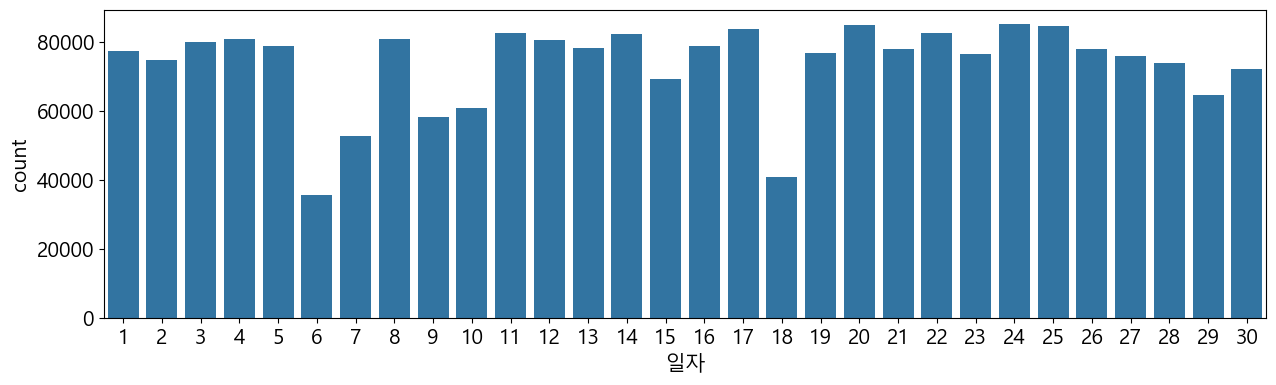

In [44]:
# 일자별 따릉이 이용건수 그래프 그리기
plt.figure(figsize=(15,4))

sns.countplot(data = bikes, x = '일자')
plt.show()

In [ ]:
# 2019년 9월 6일은 현충일, 18일은 비가 내렸음

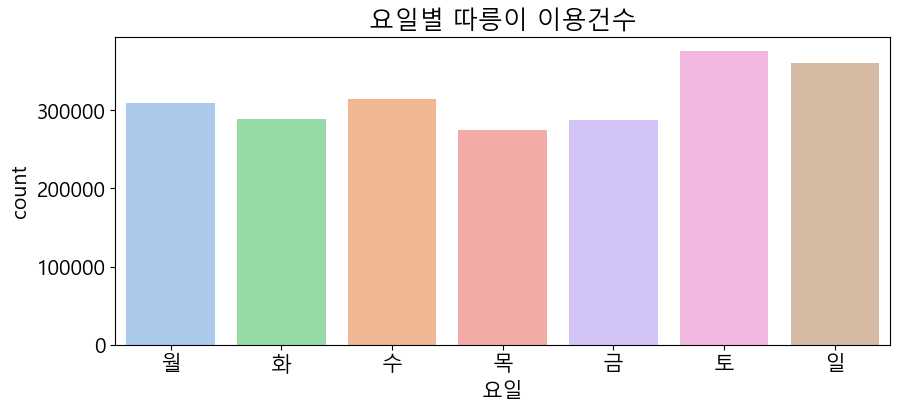

In [50]:
#요일별 따릉이 이용건수 그래프 그리기
plt.figure(figsize=(10,4))

sns.countplot(data = bikes, x = '요일', 
              hue = '요일', 
              order = ['월', '화', '수', '목', '금', '토', '일'],
              palette = 'pastel')
plt.title('요일별 따릉이 이용건수')
plt.show()

In [ ]:
# 주중보다는 주말에 이용 분포가 많다.

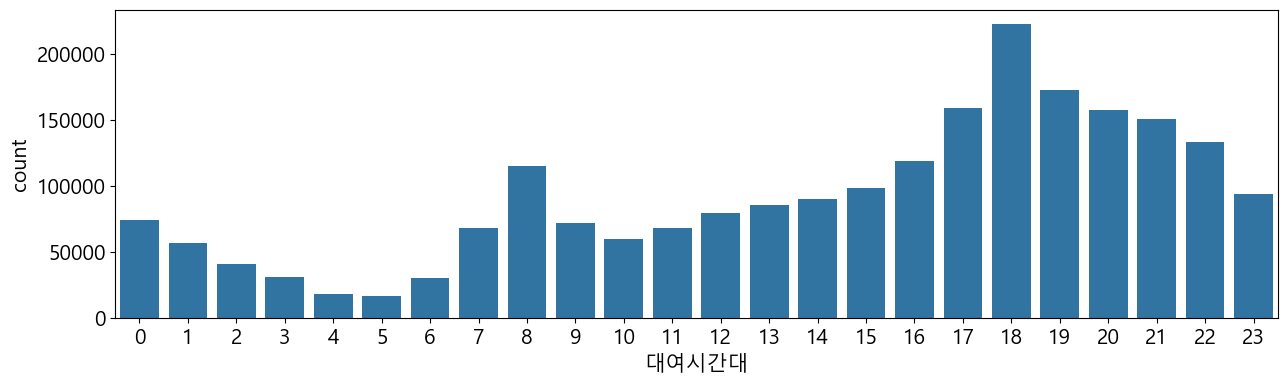

In [51]:
# 대여시간대별 따릉이 이용건수 그래프 그리기

plt.figure(figsize = (15,4))
sns.countplot(data = bikes, x = '대여시간대')
plt.show()


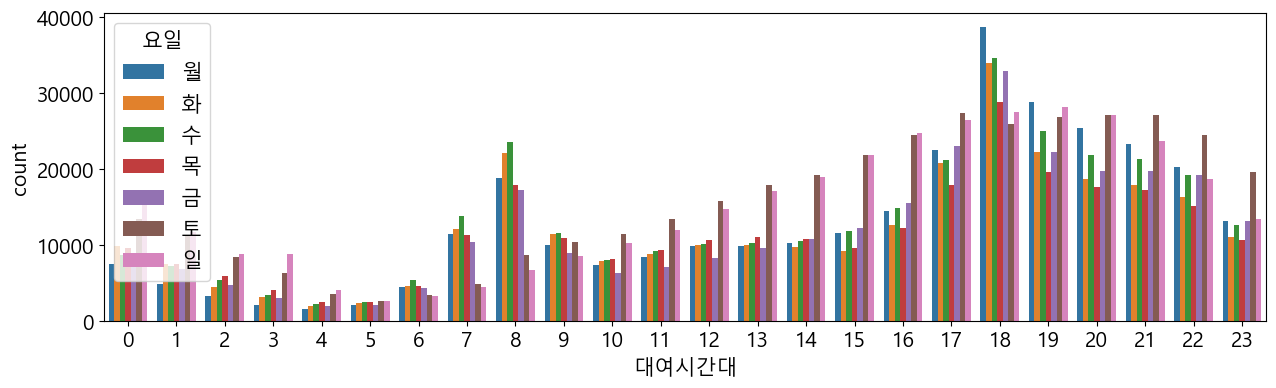

In [53]:
plt.figure(figsize = (15,4))
sns.countplot(data = bikes, x = '대여시간대', hue = '요일', hue_order = ['월', '화', '수', '목', '금', '토', '일'])
plt.show()


In [55]:
# 두가지 요인을 위해 피봇 테이블 생성하기: 대여시간대 X 요일별 자전거 이용건수
# hourly_dayofweek_ride에 저장

hourly_dayofweek_ride = bikes.pivot_table(index = '대여시간대', columns = '요일', values = '자전거번호', aggfunc = 'count')

hourly_dayofweek_ride.head()

요일,금,목,수,월,일,토,화
대여시간대,,,,,,,
0,8353,9568,8624,7461,17025,13438,9907
1,6748,7508,7226,4846,11731,11232,7529
2,4762,5857,5328,3305,8804,8348,4497
3,3045,3992,3430,2102,8748,6221,3157
4,1979,2402,2160,1544,4076,3584,1971


In [ ]:
week_order = ['월', '화', '수', '목', '금', '토', '일']

hourly_dayofweek_ride = hourly_dayofweek_ride[week_order]
hourly_dayofweek_ride.head()

요일,월,화,수,목,금,토,일
대여시간대,,,,,,,
0,7461,9907,8624,9568,8353,13438,17025
1,4846,7529,7226,7508,6748,11232,11731
2,3305,4497,5328,5857,4762,8348,8804
3,2102,3157,3430,3992,3045,6221,8748
4,1544,1971,2160,2402,1979,3584,4076


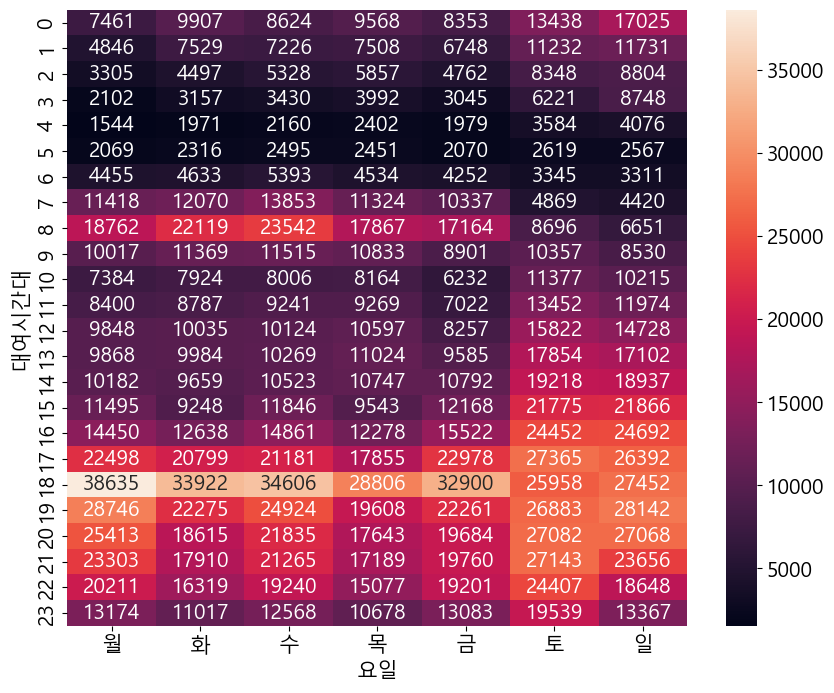

In [73]:
# sns의 대여시간대 X 요일이용건수 히트맵그래프 그리기


plt.figure(figsize = (10, 8))
sns.heatmap(data = hourly_dayofweek_ride, annot = True, fmt = 'd')
plt.show()

In [ ]:
# hourly_dayofweek_ride를 이용하여 대여시간대 X 요일이용건수 선그래프 그리기



<Axes: title={'center': '대여시간대 X 요일이용건수'}, xlabel='대여시간대'>

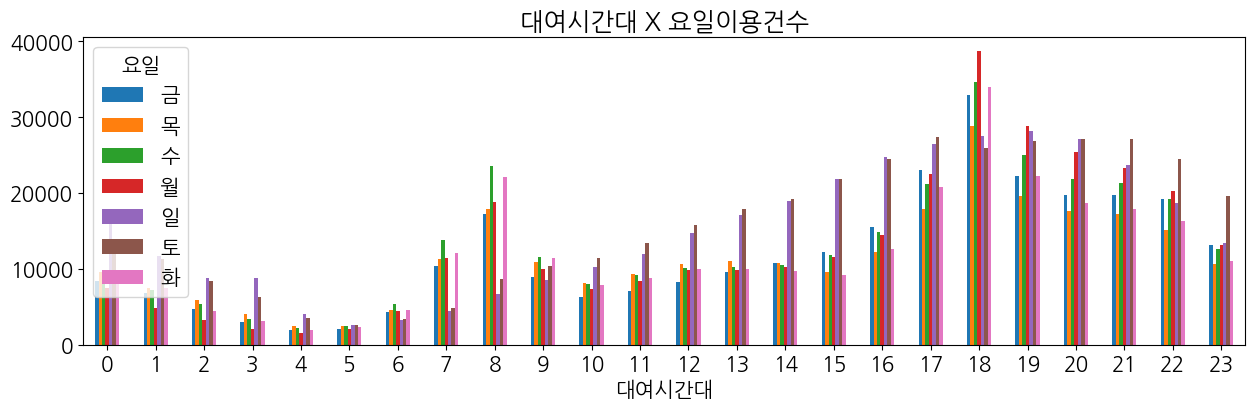

In [ ]:
# hourly_dayofweek_ride를 이용하여 대여시간대 X 요일이용건수 막대대그래프 그리기


In [ ]:
### sns.countplot() 사용하기

<Axes: xlabel='대여시간대', ylabel='count'>

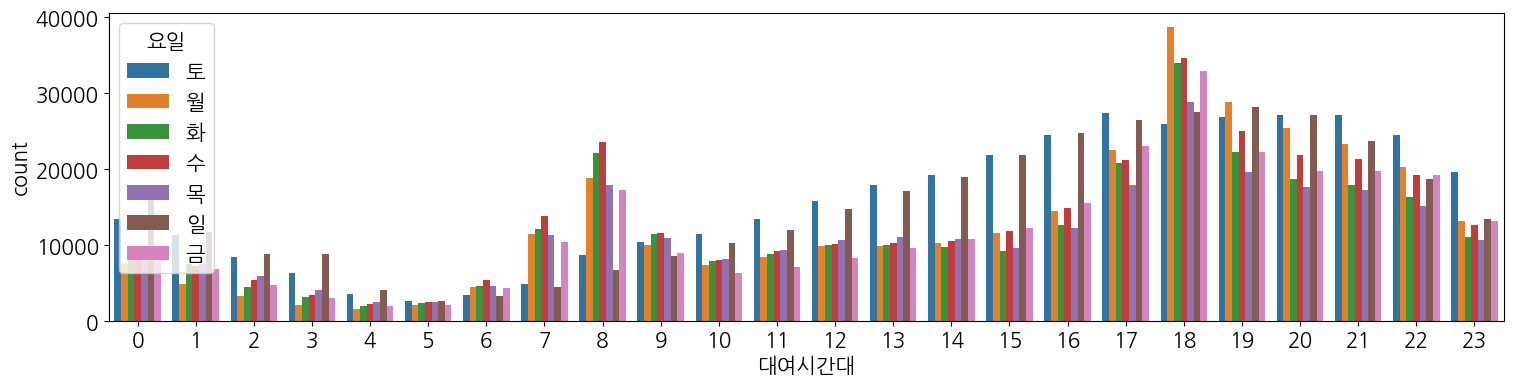

In [ ]:
# sns.countplot()를 이용하여 대여시간대 X 요일이용건수 막대그래프 그리기

plt.figure(figsize=(18,4))


## 6. 주말 구분 시각화 

In [66]:
bikes.head(3)

,자전거번호,대여일시,대여 대여소번호,대여 대여소명,이용시간,이용거리,일자,대여시간대,요일,주말구분,구분,위도,경도
0,SPB-22040,2019-06-03 08:49:00,646,장한평역 1번출구 (국민은행앞),27,1330,3,8,월,평일,동대문구,37.56,127.06
1,SPB-07446,2019-06-03 08:33:00,526,용답토속공원 앞,54,1180,3,8,월,평일,성동구,37.56,127.06
2,SPB-20387,2019-06-05 08:27:00,646,장한평역 1번출구 (국민은행앞),12,1930,5,8,수,평일,동대문구,37.56,127.06


In [71]:
## 주말 구분이 들어간 피봇 테이블 설정하기 weekdays_hourly_ride

weekdays_hourly_ride = bikes.pivot_table(index = '대여시간대', columns = '주말구분', values = '자전거번호', aggfunc = 'count')

weekdays_hourly_ride.head()


주말구분,주말,평일
대여시간대,,
0,30463,43913
1,22963,33857
2,17152,23749
3,14969,15726
4,7660,10056


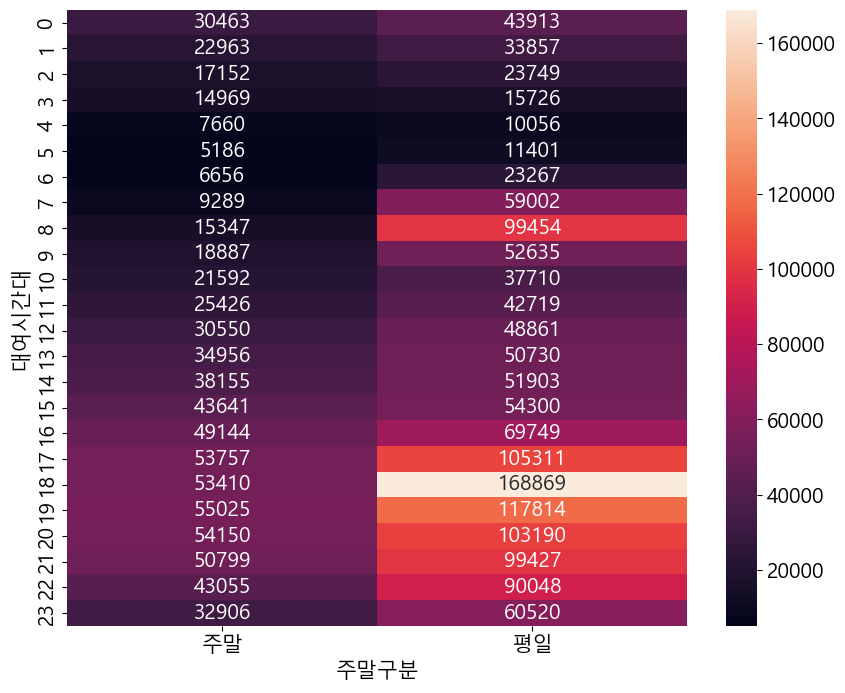

In [72]:
# sns를 이용하여 대여시간대 X 주말이용건수 히트맵 그리기


plt.figure(figsize = (10, 8))
sns.heatmap(data = weekdays_hourly_ride, annot = True, fmt = 'd')
plt.show()

<Axes: title={'center': '대여시간대 X 주말이용건수'}, xlabel='대여시간대'>

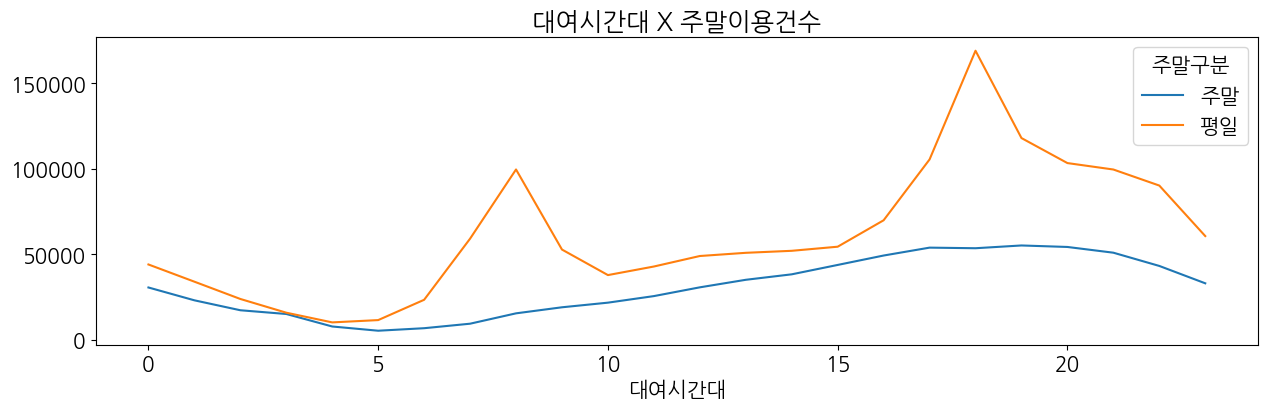

In [ ]:
# weekdays_hourly_ride를 이용하여 대여시간대 X 주말이용건수 선그래프 그리기


<Axes: title={'center': '대여시간대 X 주말이용건수'}, xlabel='대여시간대'>

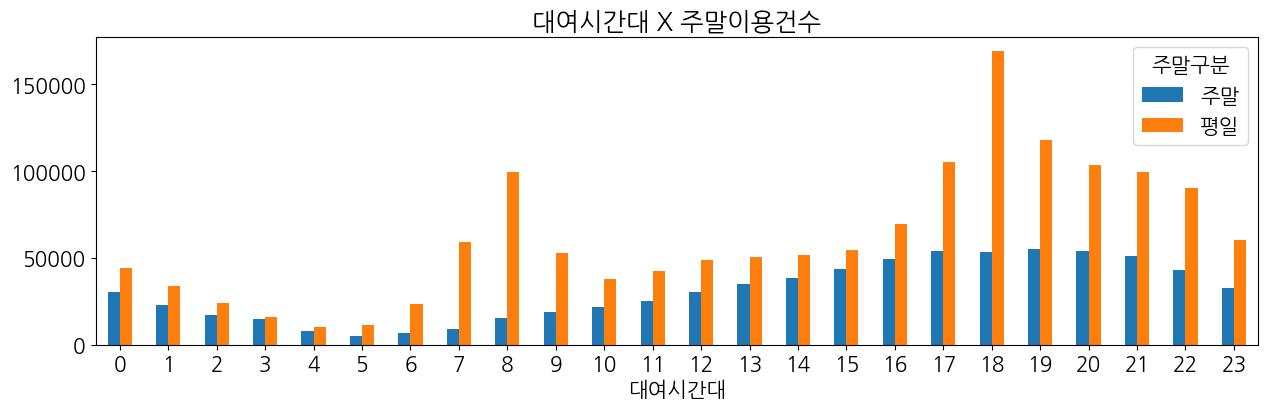

In [ ]:
# weekdays_hourly_ride를 이용하여 대여시간대 X 주말이용건수 막대그래프 그리기


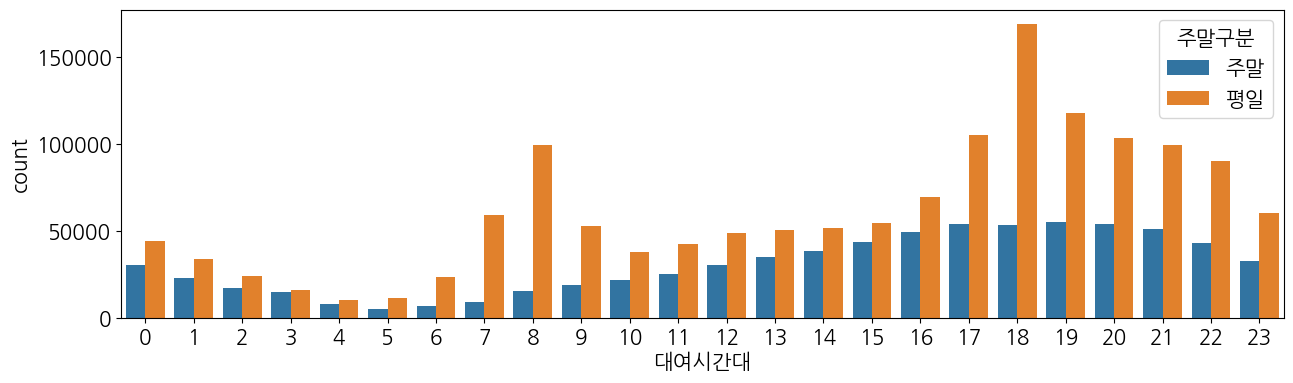

In [ ]:
# sns.countplot을 이용하여 대여시간대 X 주말이용건수 선그래프 그리기

plt.figure(figsize=(15, 4))


## 7. 장소에 따른 시각화 folium

In [74]:
bikes.head(1)

,자전거번호,대여일시,대여 대여소번호,대여 대여소명,이용시간,이용거리,일자,대여시간대,요일,주말구분,구분,위도,경도
0,SPB-22040,2019-06-03 08:49:00,646,장한평역 1번출구 (국민은행앞),27,1330,3,8,월,평일,동대문구,37.56,127.06


In [81]:
# 대여구별 이용건수 피봇테이블 만들기, 구별자전거이용건수

abc = bikes.pivot_table(index='대여구', values='자전거번호', aggfunc='count')

abc 

KeyError: '대여구'

In [ ]:
# 구별자전거이용건수 데이터프레임을 이용건수를 기준으로 오름차순으로 정렬하기


구별자전거이용건수

,자전거번호
대여구,
금천구,33488
도봉구,38697
강북구,40563
용산구,47993
중구,48533
동작구,54094
중랑구,56413
은평구,62996
양천구,64154


<Axes: title={'center': '대여구별 자전거 이용건수'}, ylabel='대여구'>

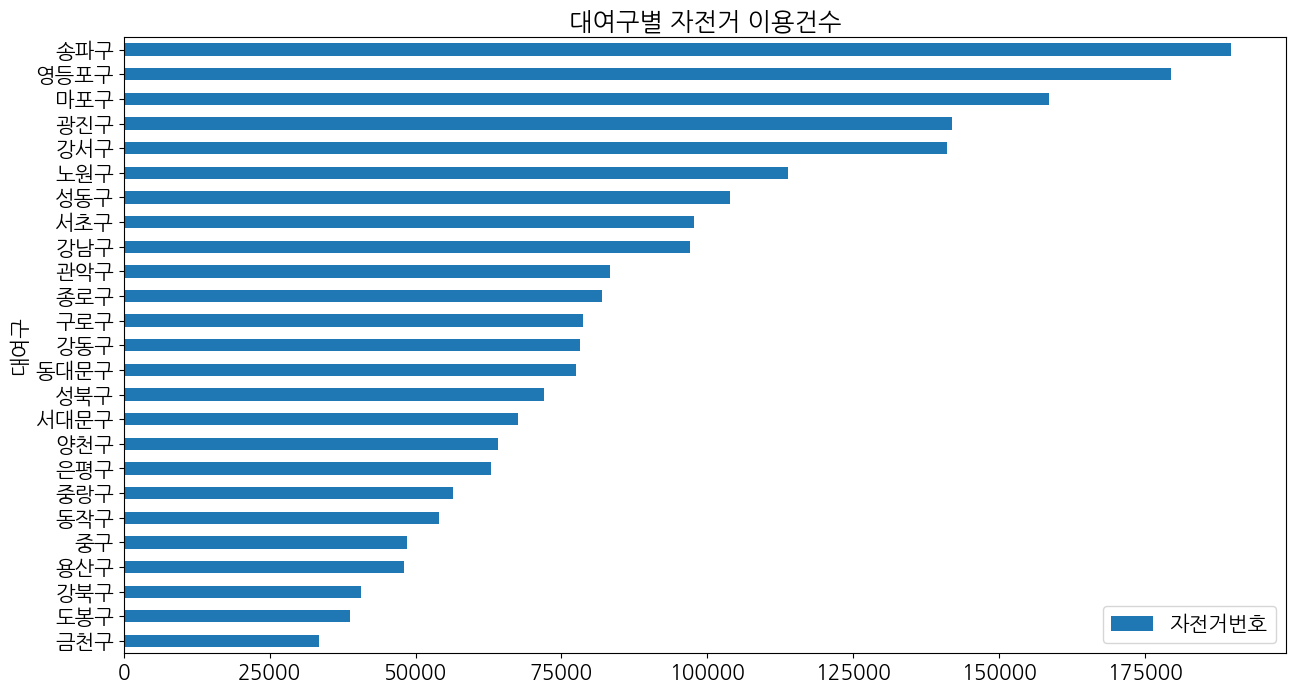

In [ ]:
# 구별자전거이용건수 수평막대그래프 그리기


In [ ]:
# 구별자전거이용건수 인덱스 번호 초기화하기기

구별자전거이용건수.head(2)

,대여구,자전거번호
0,금천구,33488
1,도봉구,38697


In [ ]:
# 서울시 지도파일 정보 로드하기기

import json
with open('data/seoul.json','r', encoding='utf-8') as f:
    서울시지도 = json.load(f)

In [ ]:
서울시지도

{'type': 'FeatureCollection',
 'features': [{'type': 'Feature',
   'properties': {'code': '11250',
    'name': '강동구',
    'name_eng': 'Gangdong-gu',
    'base_year': '2013'},
   'geometry': {'type': 'Polygon',
    'coordinates': [[[127.11519584981606, 37.557533180704915],
      [127.11540412678968, 37.557491025257455],
      [127.1165206546129, 37.557268061772696],
      [127.1175954493625, 37.55705301284316],
      [127.11879551821994, 37.557222485451305],
      [127.11969651045837, 37.558176474822524],
      [127.12057912633198, 37.5590144597372],
      [127.12146867175024, 37.55986003393365],
      [127.12240146859469, 37.5604208685133],
      [127.12287911525227, 37.56070873375976],
      [127.12303576608339, 37.56078573052513],
      [127.12435254630417, 37.56144246249796],
      [127.12447748580927, 37.56148569898355],
      [127.13349006006634, 37.56465664804646],
      [127.13357625665371, 37.56468978043648],
      [127.1336638698021, 37.56472375596808],
      [127.133755022522

In [ ]:
# 지도에 나타내기 위해 대여점 위도와 대여점 경도의 평균값 구하기

lat = 
lon = 
print(lat, lon)

37.54734988442208 126.99171375924


In [ ]:
# 지도에 위치 표시하기 folium.Map() 함수 이용

map1 = 
map1

In [ ]:
# 지도위에 구별자전거 이용건수 시각화하기 folium.Choropleth() 사용


map1


In [ ]:
## 미션: 구별이용시간평균 지도에 나타내기 ##

In [ ]:
# 대여구별 이용시간평균 (이용시간)
# 1단계 : 피봇 테이블 만들기

구별이용시간평균 = 
구별이용시간평균

,이용시간
대여구,
강남구,31.79
강동구,25.39
강북구,23.57
강서구,23.14
관악구,26.51
광진구,24.95
구로구,26.48
금천구,26.40
노원구,24.26


In [ ]:
#이용시간 컬럼을 기준으로 오름차순 정렬

구별이용시간평균

,이용시간
대여구,
강서구,23.14
성북구,23.17
종로구,23.32
강북구,23.57
동대문구,23.78
중랑구,24.24
노원구,24.26
광진구,24.95
도봉구,24.99


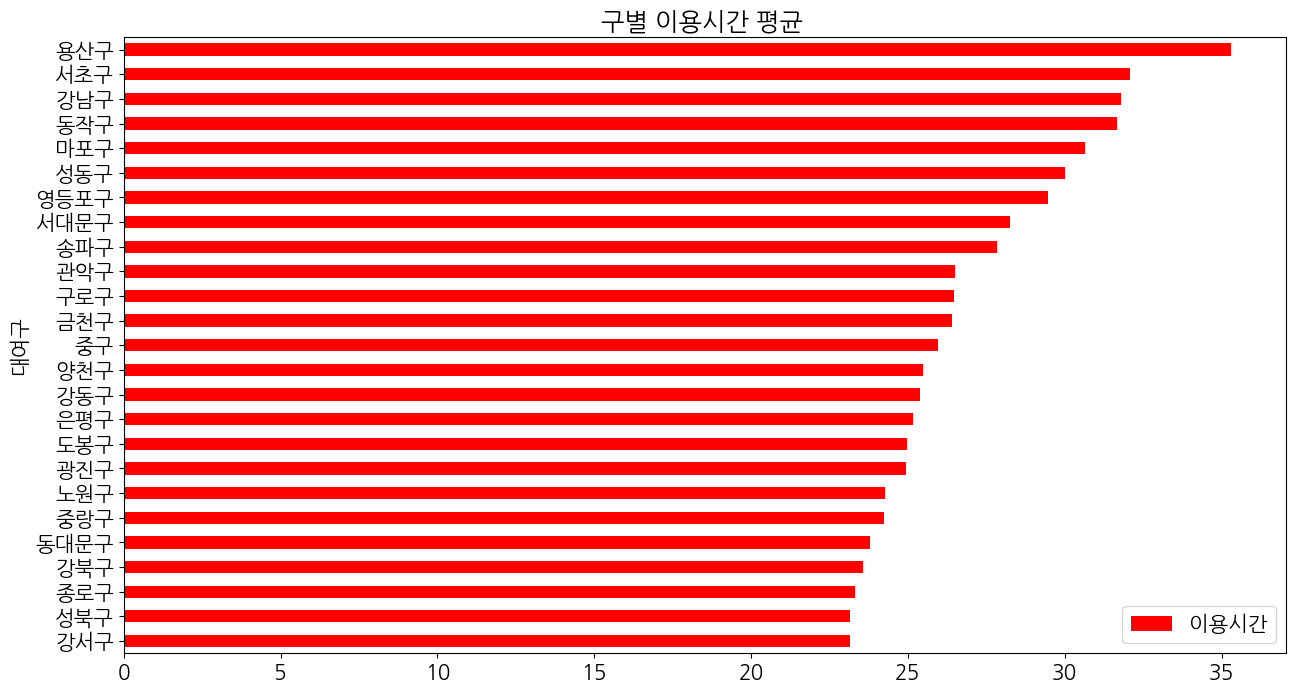

In [ ]:
# 구별 이용시간 평균 reset_index


구별이용시간평균

,대여구,이용시간
0,강서구,23.14
1,성북구,23.17
2,종로구,23.32
3,강북구,23.57
4,동대문구,23.78
5,중랑구,24.24
6,노원구,24.26
7,광진구,24.95
8,도봉구,24.99
9,은평구,25.16


In [ ]:
#지도 표시하기

map2


In [ ]:
#구별이용기간 평균에 사용하여 지도를 시각화

map2

## 8 . 시간적 X 장소적

In [ ]:
# pivot_table로 대여일자X 대여구별 따릉이 이용건수 계산하기, daily_gu_use

daily_gu_use = 
daily_gu_use

대여구,강남구,강동구,강북구,강서구,관악구,광진구,구로구,금천구,노원구,도봉구,...,성동구,성북구,송파구,양천구,영등포구,용산구,은평구,종로구,중구,중랑구
일자,,,,,,,,,,,,,,,,,,,,,
1,3227,2774,1460,4476,3030,5215,2604,934,4015,1366,...,3505,2516,7206,2229,6327,1879,2286,2688,1561,1977
2,3071,2582,1518,4250,3198,5102,2526,916,3943,1351,...,3628,2444,6545,2056,6270,1883,2184,2463,1387,1807
3,3873,2734,1398,4987,3033,5290,2879,1340,4097,1414,...,3676,2620,6233,2186,6813,1663,2170,3090,1837,2047
4,3601,2820,1414,5120,3030,5213,2981,1281,4451,1441,...,3998,2728,6587,2364,6483,1543,2182,2896,1836,2082
5,3303,2735,1442,5280,3036,4879,2829,1294,4341,1385,...,3672,2573,6501,2278,6296,1595,2176,3120,1939,2113
6,1449,1371,743,2125,1448,2298,1282,456,2101,729,...,1659,1360,3050,1005,2566,739,1147,1209,669,1096
7,2458,1878,899,3320,1959,3201,1870,674,2746,880,...,2481,1733,4676,1551,4388,1148,1536,1994,1090,1218
8,3345,2978,1540,4712,3343,5437,2787,953,4159,1493,...,3629,2623,7369,2372,6859,1927,2370,2573,1472,2084
9,2380,2194,1216,3354,2561,3772,1922,661,3134,1120,...,2719,2088,5236,1706,4538,1316,1668,2069,1126,1514


<Axes: xlabel='대여구', ylabel='일자'>

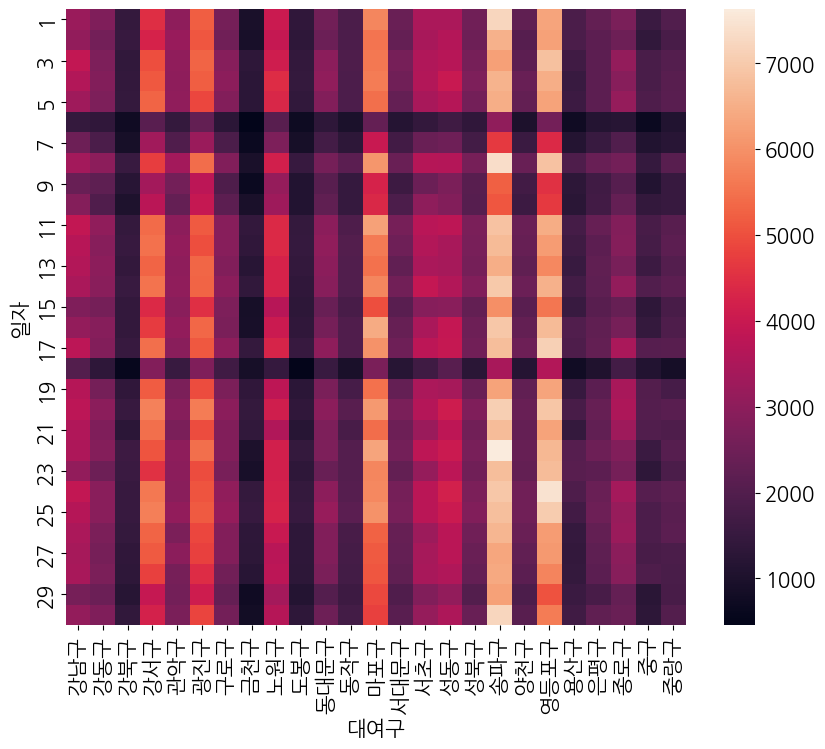

In [ ]:
# 대여일자X 대여구별 따릉이 이용건수 히트맵으로 표시하기기

plt.figure(figsize=(10,8))


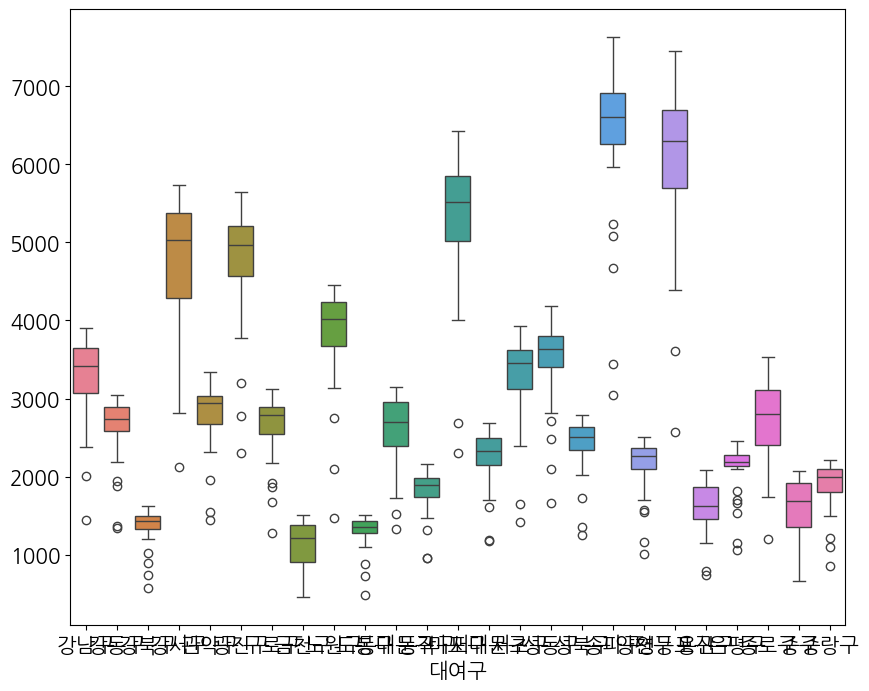

In [ ]:
# 대여일자X 대여구별 따릉이 이용건수 박스플롯으로 그리기

plt.figure(figsize=(10,8))


In [ ]:
## 미션: 대여시간대별 ##

In [ ]:
## 대여시간대 X 대여구 따릉이 이용건수 계산하기

hourly_gu_use = 
hourly_gu_use

대여구,강남구,강동구,강북구,강서구,관악구,광진구,구로구,금천구,노원구,도봉구,...,성동구,성북구,송파구,양천구,영등포구,용산구,은평구,종로구,중구,중랑구
대여시간대,,,,,,,,,,,,,,,,,,,,,
0,2643,3230,2066,4459,3769,5314,2650,790,4855,1529,...,3003,3165,6014,2091,4892,1641,2389,1697,1180,2369
1,2660,2342,1706,3306,2830,3621,1797,650,3632,1297,...,2096,2501,5150,1770,3314,1334,1873,1299,893,1944
2,2360,1852,1378,2442,1899,2469,1291,496,2610,853,...,1394,1941,3339,1143,2190,935,1330,978,683,1413
3,1689,1398,932,1909,1550,1830,853,328,1932,668,...,1103,1337,2390,859,1627,755,977,749,564,1171
4,920,620,595,1152,990,998,572,173,1052,403,...,743,701,1252,479,1109,512,508,552,407,580
5,648,686,392,1072,745,992,543,161,829,416,...,698,522,1086,565,1140,305,527,741,442,597
6,1316,1173,499,2144,1042,1687,1081,511,1413,498,...,1092,1089,2326,988,2682,541,1025,1079,538,826
7,2404,2420,1047,4854,2800,3512,3091,1623,2841,1120,...,2588,2297,5214,2674,6516,1094,2430,2664,1259,2128
8,4951,3728,1533,9357,4350,6988,4691,3337,4491,1541,...,5446,3763,9105,3886,9939,1866,3420,4317,2262,3061


<Axes: xlabel='대여시간대', ylabel='대여구'>

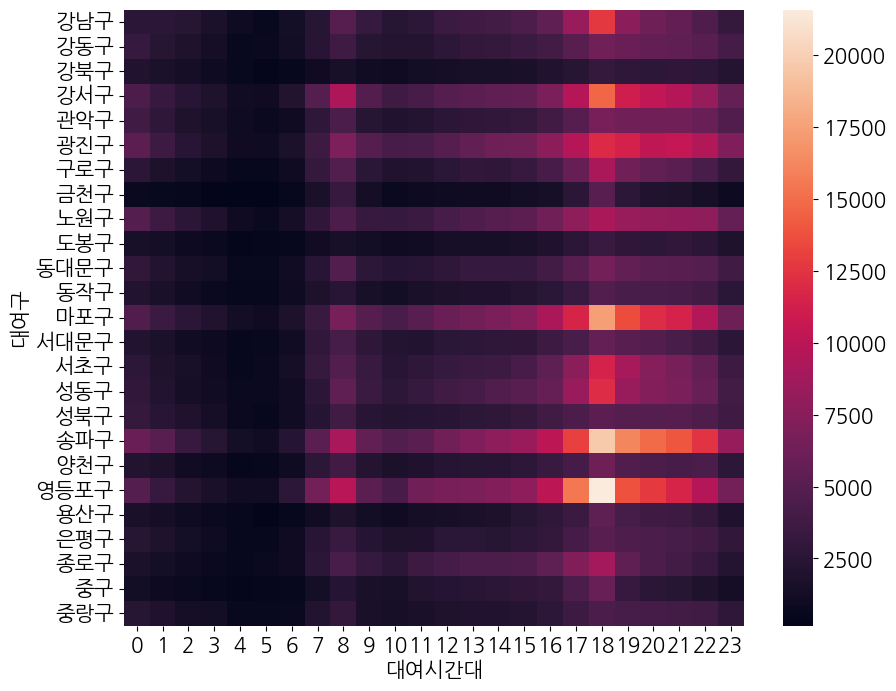

In [ ]:
#히트맵
plt.figure(figsize=(10,8))

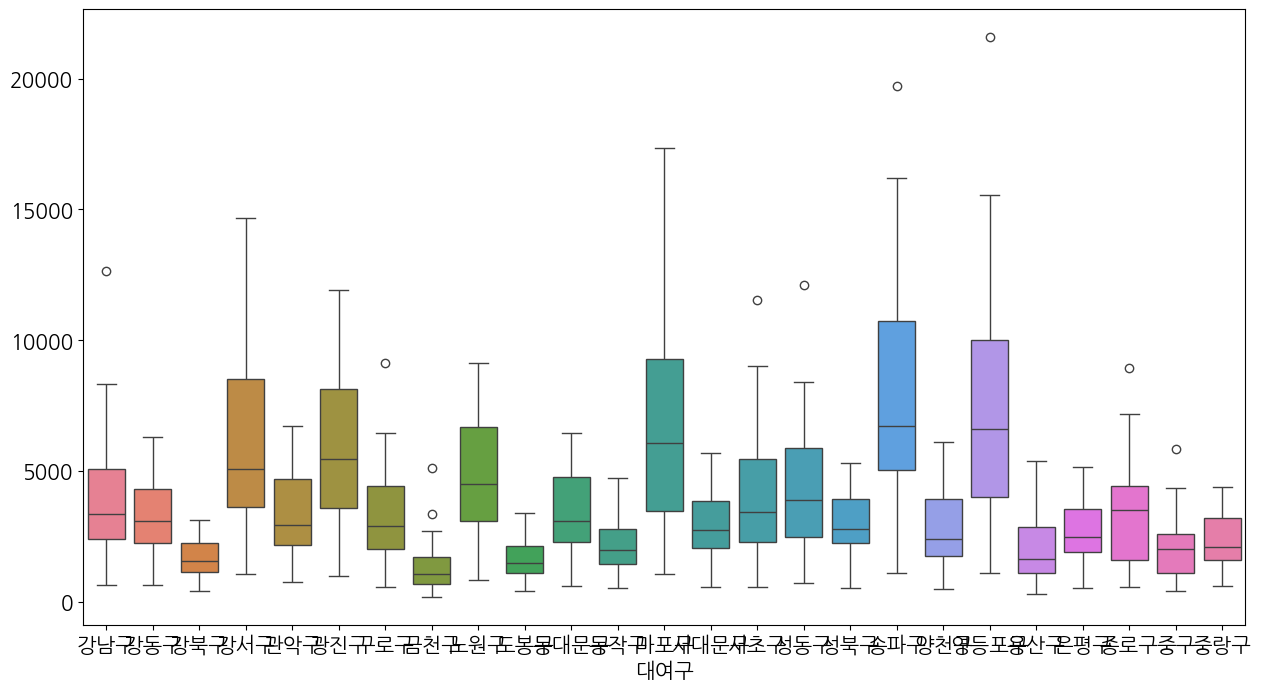

In [ ]:
# 박스 그래프로 표기
plt.figure(figsize=(15,8))

## 9. TOP 50


In [ ]:
# 미션: 서울시에서 주말에 인기있는 TOP 대여소 지도에 표시하기
# 미션: 서울시에서 평일일에 인기있는 TOP 대여소 지도에 표시하기

In [ ]:
## 대여 대여소  X 주말 구분 이용건수 계산을 위한 피벗 테이블



,,주말구분,주말,평일
대여 대여소명,대여점위도,대여점경도,,
(구)신한은행 중랑교지점,37.60,127.08,391,832
(구)합정동 주민센터,37.55,126.91,357,715
3호선 매봉역 3번출구앞,37.49,127.05,443,1049
419민주묘지역,37.65,127.01,547,946
8삼호@ 2동 ( 간선도로),37.49,127.05,111,316
...,...,...,...,...
휘봉고등학교 앞,37.59,127.07,193,370
흑석역 1번출구,37.51,126.96,1297,2195
흑석역 4번출구,37.51,126.96,184,412


In [ ]:
# 대여 대여소  X 주말 구분 이용건수 계산을 위한 피벗 테이블 만들기 
# '대여 대여소명','대여점위도','대여점경도'

rent_bikes = 
rent_bikes

,,주말구분,주말,평일
대여 대여소명,대여점위도,대여점경도,,
(구)신한은행 중랑교지점,37.60,127.08,391,832
(구)합정동 주민센터,37.55,126.91,357,715
3호선 매봉역 3번출구앞,37.49,127.05,443,1049
419민주묘지역,37.65,127.01,547,946
8삼호@ 2동 ( 간선도로),37.49,127.05,111,316
...,...,...,...,...
휘봉고등학교 앞,37.59,127.07,193,370
흑석역 1번출구,37.51,126.96,1297,2195
흑석역 4번출구,37.51,126.96,184,412


In [ ]:
# 인기있는 주말 대여점 50개를 구하기


,,주말구분,주말,평일
대여 대여소명,대여점위도,대여점경도,,
뚝섬유원지역 1번출구 앞,37.53,127.07,5777,6840
여의나루역 1번출구 앞,37.53,126.93,5286,6241
"고속터미널역 8-1번, 8-2번 출구 사이",37.51,127.00,3932,4556
봉림교 교통섬,37.48,126.93,3699,5986
롯데월드타워(잠실역2번출구 쪽),37.51,127.10,3231,5383
마포구민체육센터 앞,37.56,126.90,3229,3893
건대입구역 사거리(롯데백화점),37.54,127.07,3169,4573
홍대입구역 2번출구 앞,37.56,126.92,2922,5617
잠실새내역 5번 출구 뒤,37.51,127.09,2632,3660


In [ ]:
# 인기있는 주말 대여점 50개중 '주말' 컬럼만 추출


대여 대여소명                  대여점위도  대여점경도 
뚝섬유원지역 1번출구 앞            37.53  127.07    5777
여의나루역 1번출구 앞             37.53  126.93    5286
고속터미널역 8-1번, 8-2번 출구 사이  37.51  127.00    3932
봉림교 교통섬                  37.48  126.93    3699
롯데월드타워(잠실역2번출구 쪽)        37.51  127.10    3231
마포구민체육센터 앞               37.56  126.90    3229
건대입구역 사거리(롯데백화점)         37.54  127.07    3169
홍대입구역 2번출구 앞             37.56  126.92    2922
잠실새내역 5번 출구 뒤            37.51  127.09    2632
당산육갑문                    37.54  126.90    2327
신도림역 1번 출구 앞             37.51  126.89    2304
IFC몰                     37.53  126.93    2240
합정역 7번출구 앞               37.55  126.91    2194
동방1교                     37.47  126.93    2170
서울숲 관리사무소                37.54  127.04    2141
안암로터리 버스정류장 앞            37.58  127.03    2058
올림픽공원역 3번출구              37.52  127.13    2011
CJ 드림시티                  37.60  126.92    2002
당산역 10번출구 앞              37.53  126.90    1978
노들역 1번출구                 37.51  126.95    1905
신대방역 2번 출구           

In [ ]:
# 인기있는 주말 대여점 50개중 '주말' 컬럼만 추출하여 주말대여점50에 저장장

주말대여점50 = 
주말대여점50

,대여 대여소명,대여점위도,대여점경도,주말
0,뚝섬유원지역 1번출구 앞,37.53,127.07,5777
1,여의나루역 1번출구 앞,37.53,126.93,5286
2,"고속터미널역 8-1번, 8-2번 출구 사이",37.51,127.00,3932
3,봉림교 교통섬,37.48,126.93,3699
4,롯데월드타워(잠실역2번출구 쪽),37.51,127.10,3231
5,마포구민체육센터 앞,37.56,126.90,3229
6,건대입구역 사거리(롯데백화점),37.54,127.07,3169
7,홍대입구역 2번출구 앞,37.56,126.92,2922
8,잠실새내역 5번 출구 뒤,37.51,127.09,2632
9,당산육갑문,37.54,126.90,2327


In [ ]:
# 평일대여점 데이터 프레임 만들기기
평일대여점50 = 
평일대여점50

,대여 대여소명,대여점위도,대여점경도,평일
0,뚝섬유원지역 1번출구 앞,37.53,127.07,6840
1,여의나루역 1번출구 앞,37.53,126.93,6241
2,봉림교 교통섬,37.48,126.93,5986
3,홍대입구역 2번출구 앞,37.56,126.92,5617
4,롯데월드타워(잠실역2번출구 쪽),37.51,127.10,5383
5,마곡나루역 5번출구 뒤편,37.57,126.83,4648
6,건대입구역 사거리(롯데백화점),37.54,127.07,4573
7,"고속터미널역 8-1번, 8-2번 출구 사이",37.51,127.00,4556
8,양천향교역 7번출구앞,37.57,126.84,4342
9,안암로터리 버스정류장 앞,37.58,127.03,4127


In [ ]:
## 주말 대여점50의 가운데 지점의 위도 경도 중심으로 초기 map 그리기

map3


In [ ]:
주말대여점50.head(10)


,대여 대여소명,대여점위도,대여점경도,주말
0,뚝섬유원지역 1번출구 앞,37.53,127.07,5777
1,여의나루역 1번출구 앞,37.53,126.93,5286
2,"고속터미널역 8-1번, 8-2번 출구 사이",37.51,127.00,3932
3,봉림교 교통섬,37.48,126.93,3699
4,롯데월드타워(잠실역2번출구 쪽),37.51,127.10,3231
5,마포구민체육센터 앞,37.56,126.90,3229
6,건대입구역 사거리(롯데백화점),37.54,127.07,3169
7,홍대입구역 2번출구 앞,37.56,126.92,2922
8,잠실새내역 5번 출구 뒤,37.51,127.09,2632
9,당산육갑문,37.54,126.90,2327


In [ ]:
# for문을 사용해서 주말 대여점 50지도를 시각화하기


map3


In [ ]:
## 평일 대여점 이용이 많은 대여소를 표시


map3

In [ ]:
# 시각화데이터를 통해 정보 및 인사이트 도출하기!!!!